# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


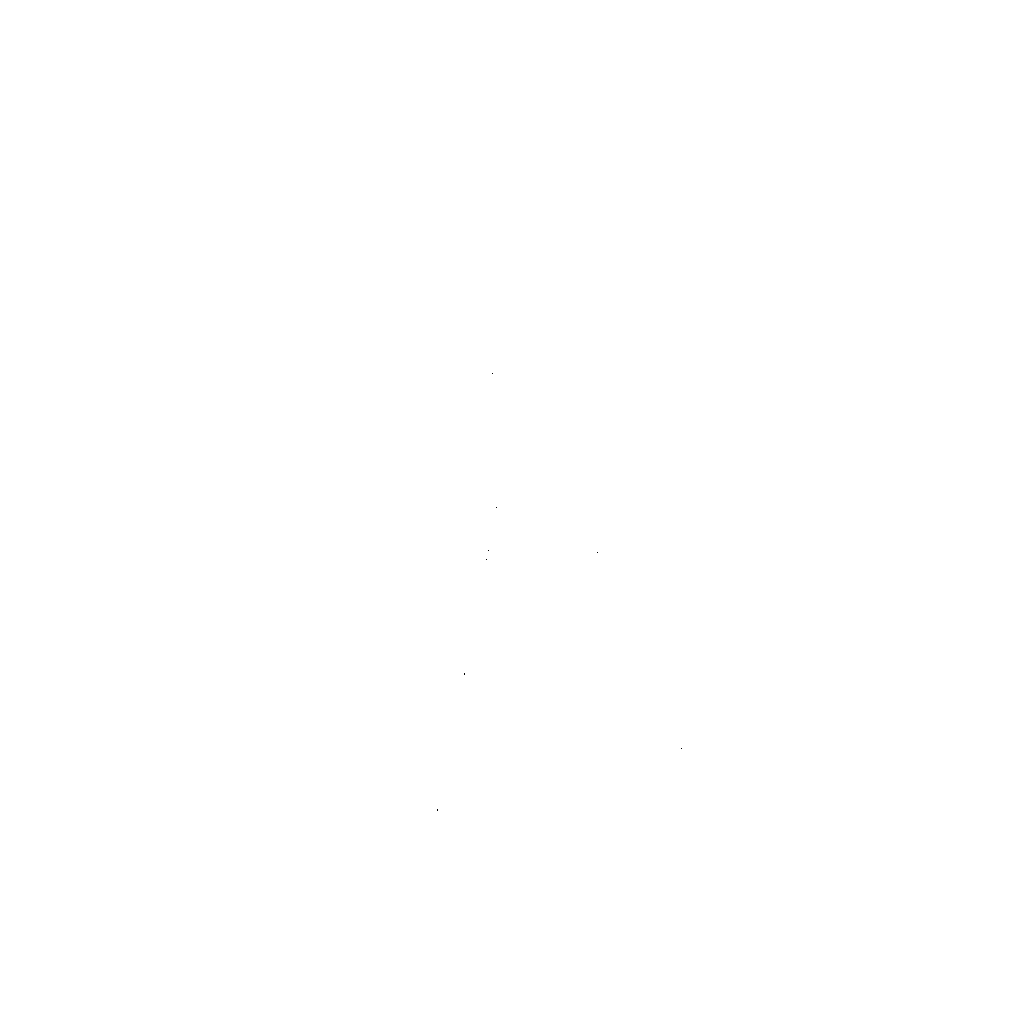

Threshold value: 50


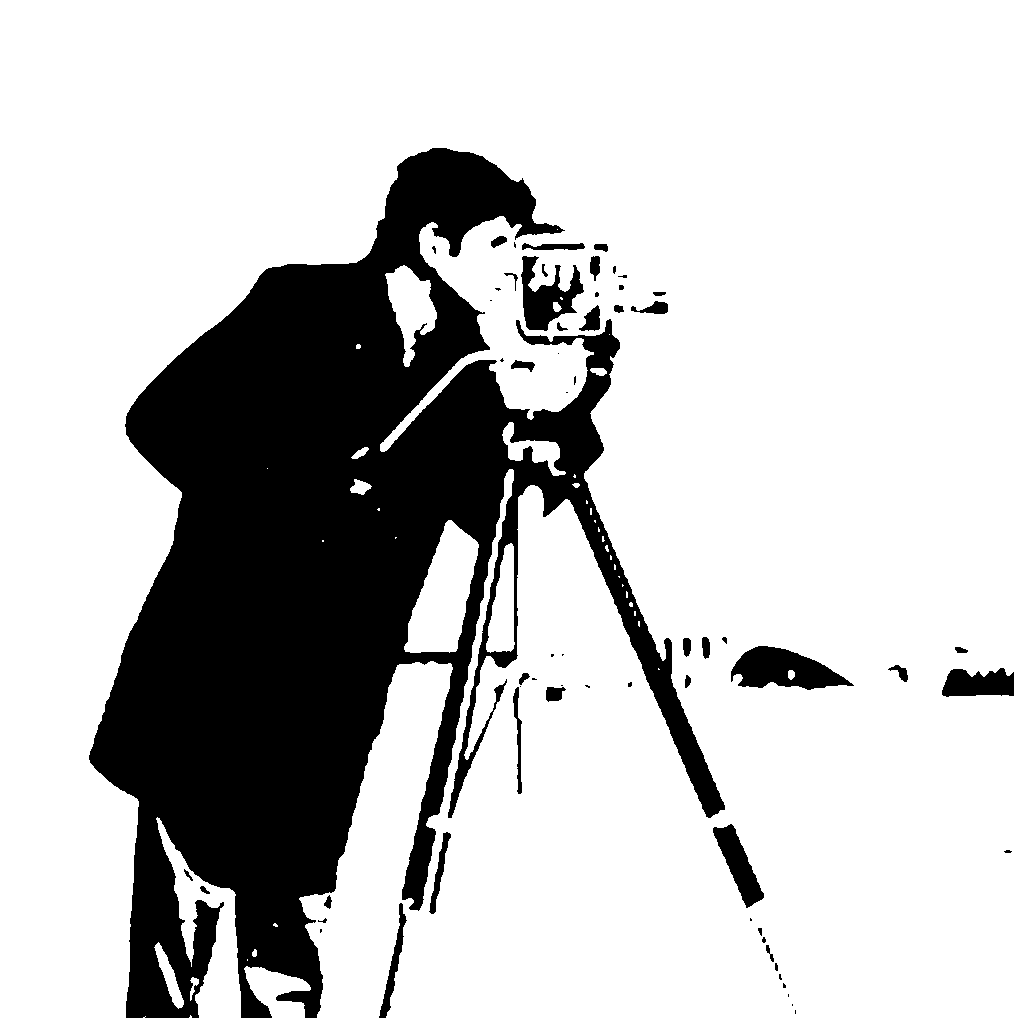

Threshold value: 100


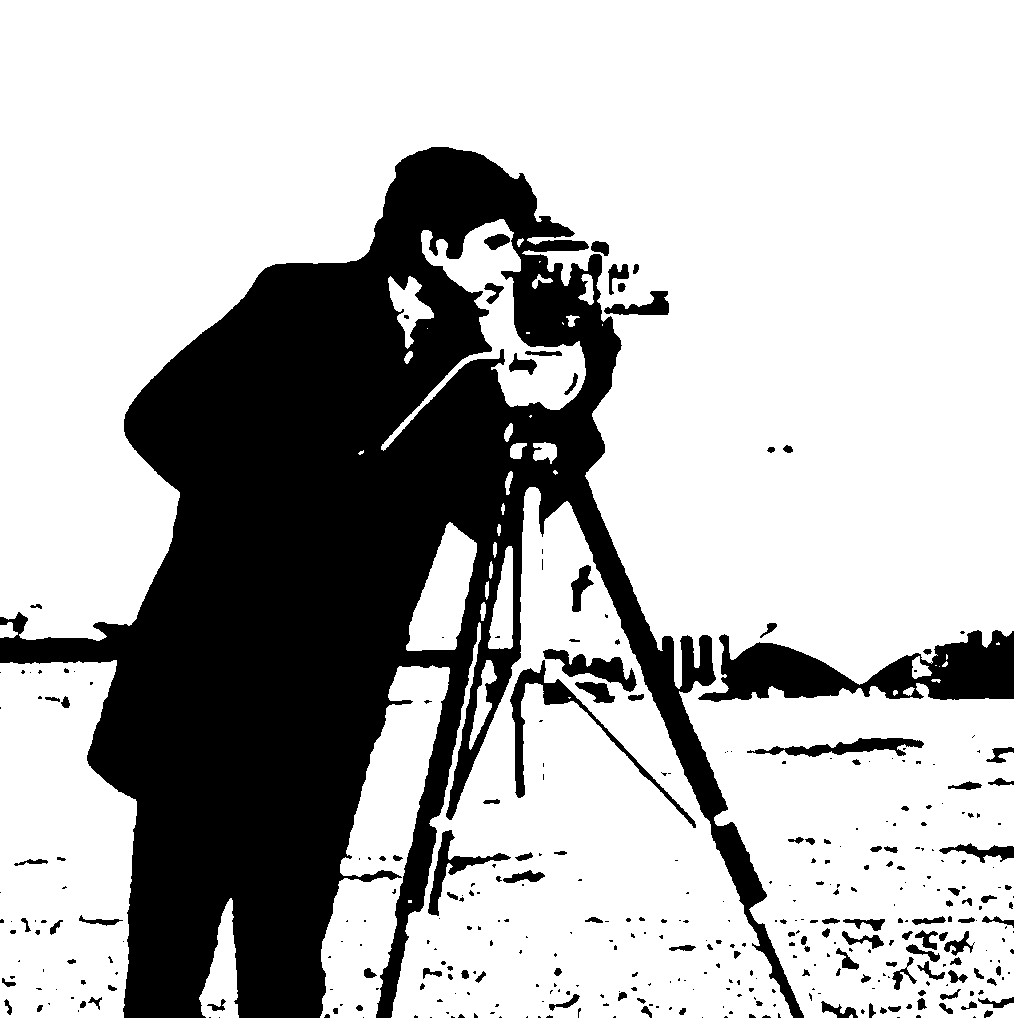

Threshold value: 150


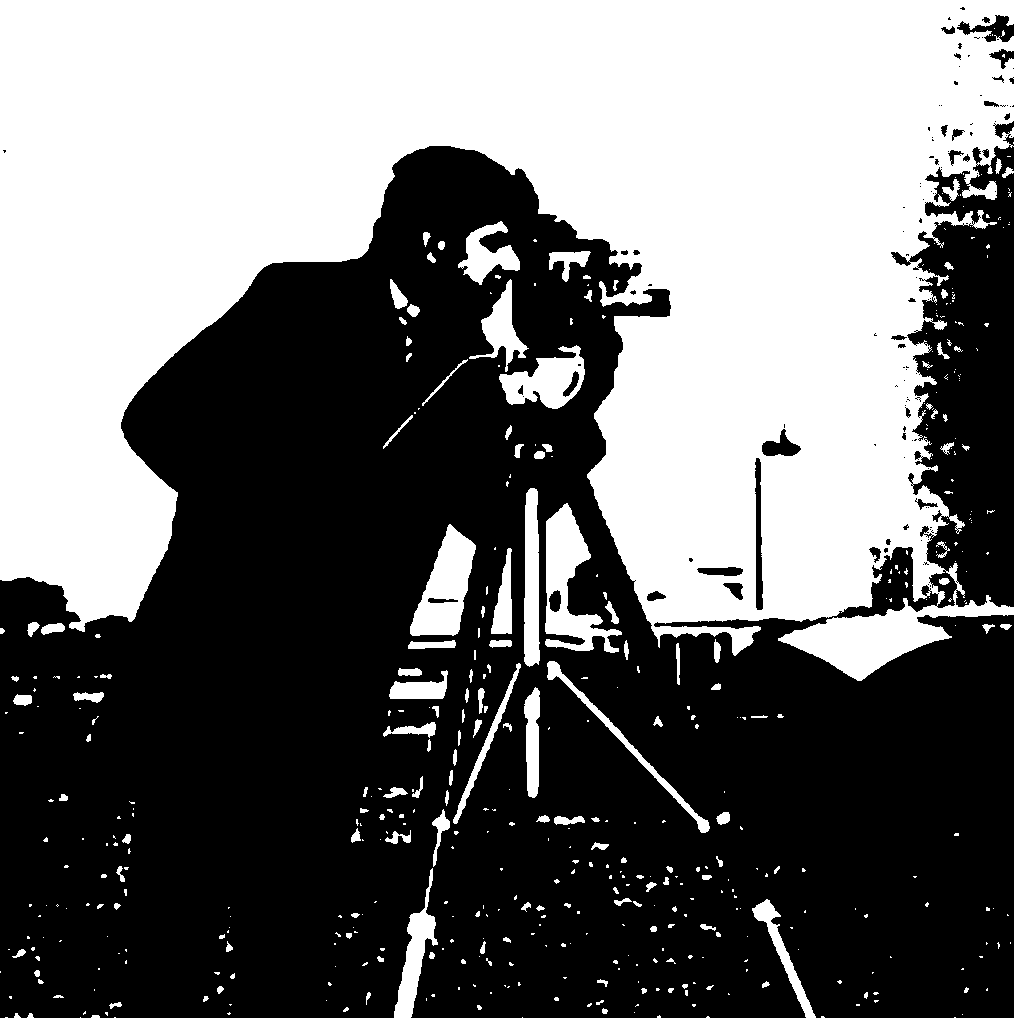

Threshold value: 200


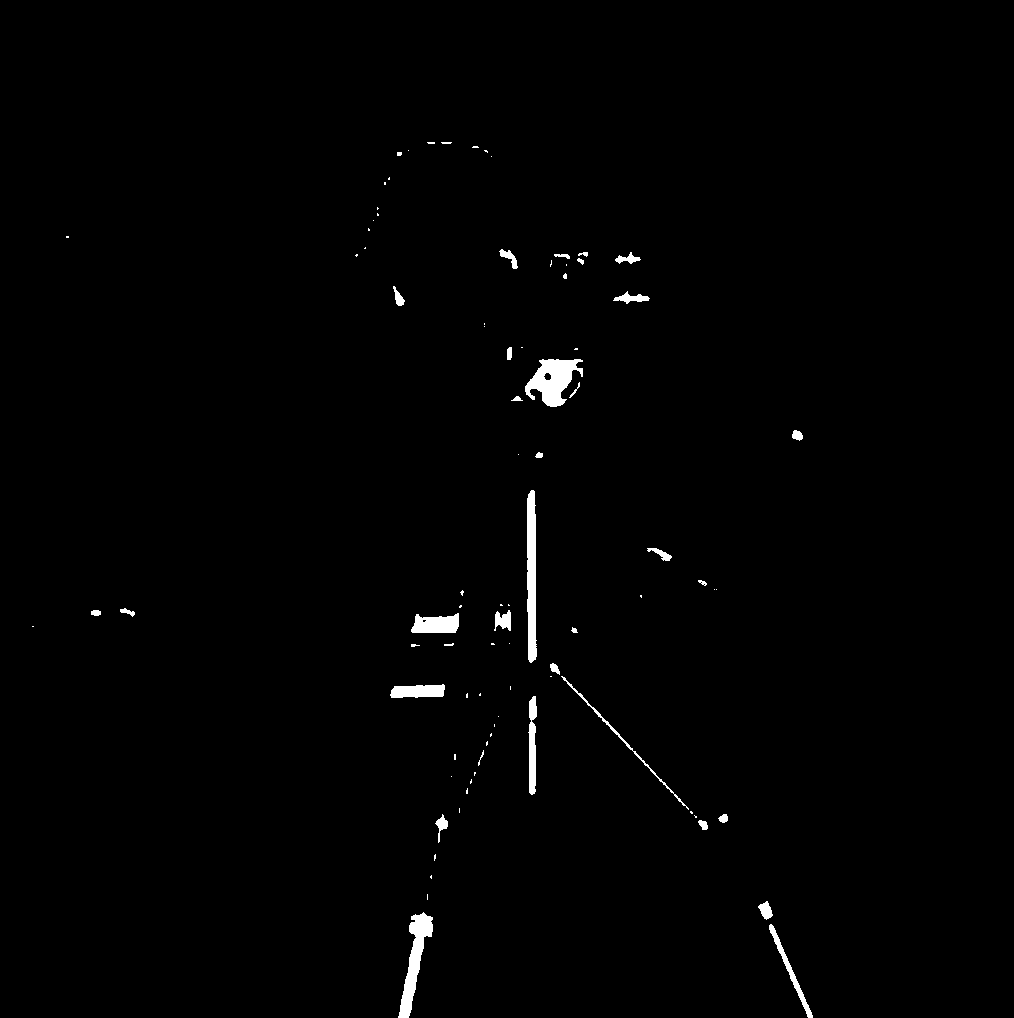

In [ ]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


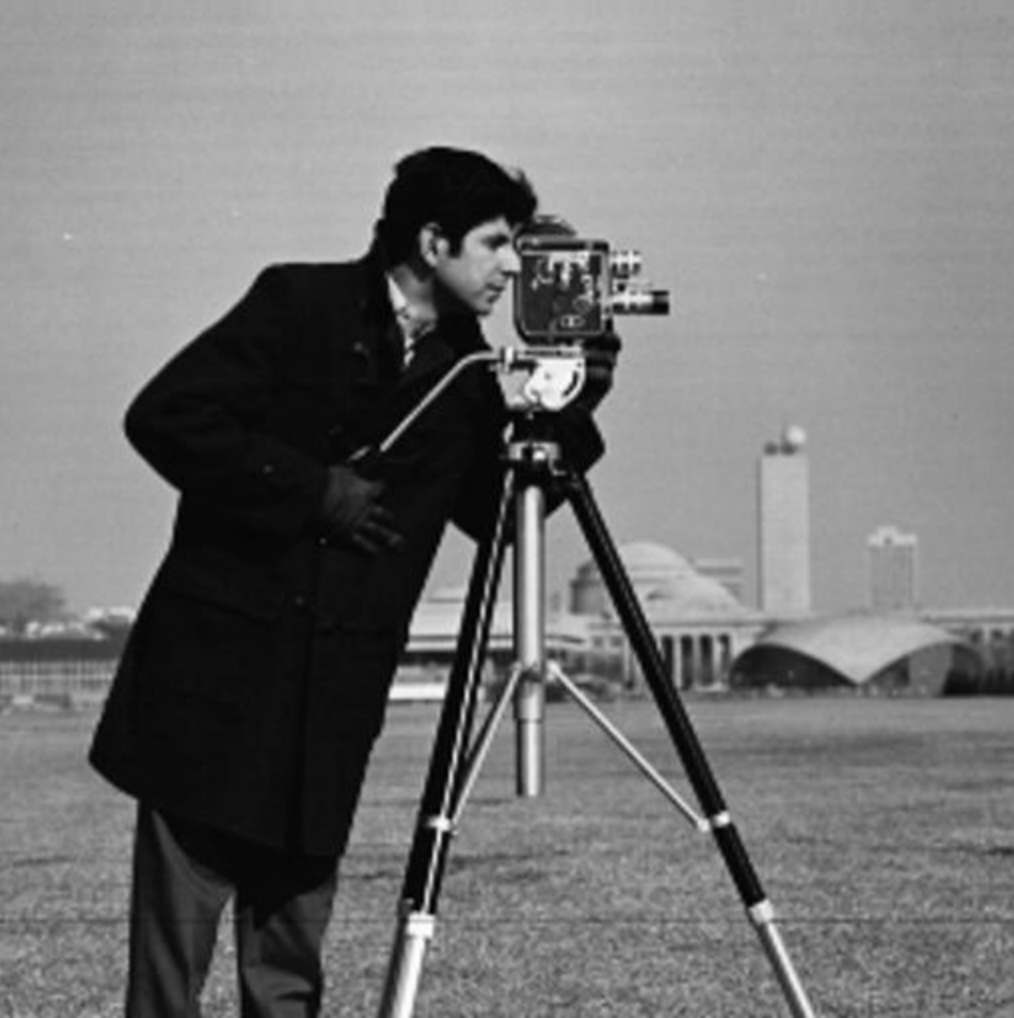

In [ ]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

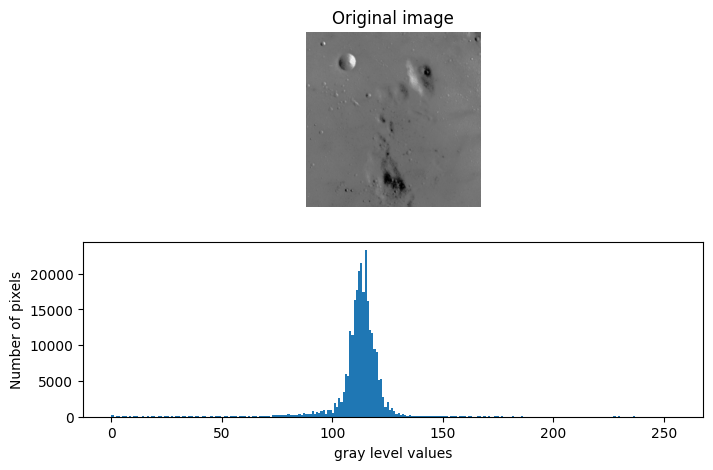

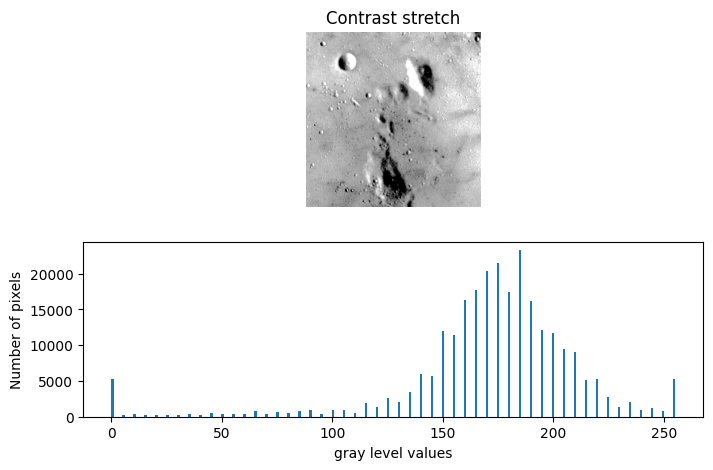

In [ ]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


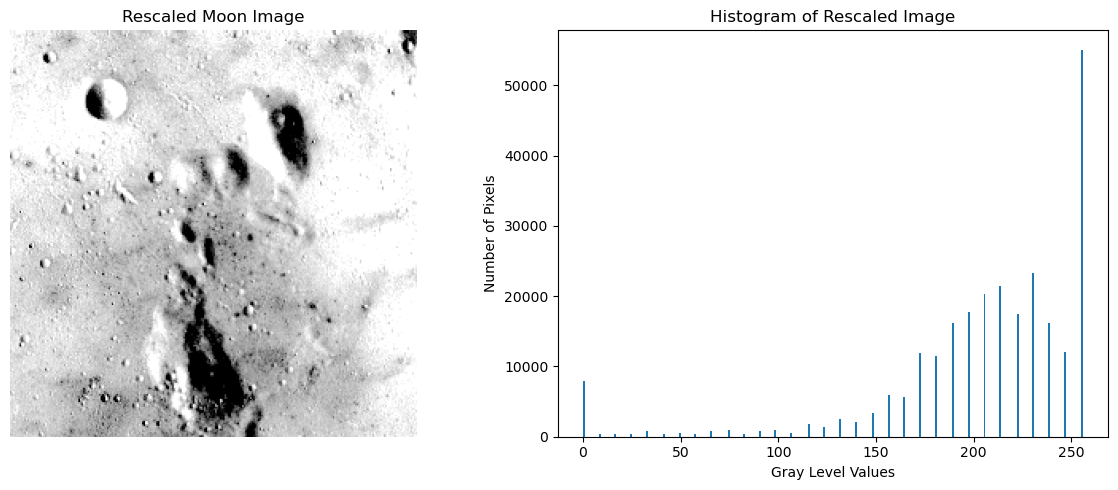

In [1]:
from skimage import data, exposure
import numpy as np
import matplotlib.pyplot as plt

# Load the moon image
moon_image = data.moon()

# Calculate the 3rd and 80th percentiles
p3, p80 = np.percentile(moon_image, (3, 80))

# Rescale the intensity values
rescaled_image = exposure.rescale_intensity(
    moon_image,
    in_range=(p3, p80)
)

# Display the rescaled image and its histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rescaled_image, cmap='gray')
plt.title('Rescaled Moon Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(rescaled_image.ravel(), bins=256, range=(0, 256))
plt.title('Histogram of Rescaled Image')
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()# Apply histogram equalization to the moon image
equalized_image = exposure.equalize_hist(moon_image)

# Display the equalized image and its histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Moon Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(equalized_image.ravel(), bins=256, range=(0, 1))
plt.title('Histogram After Equalization')
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

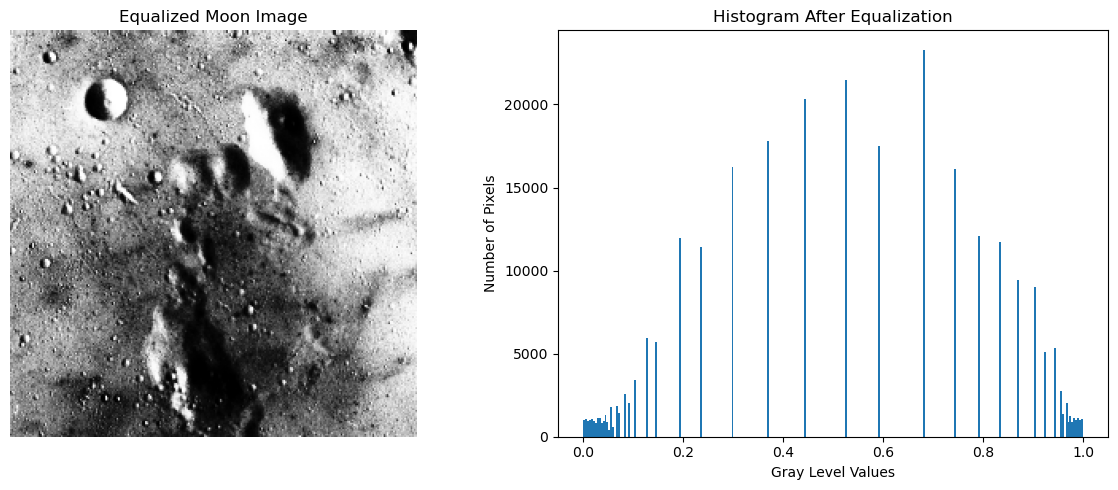

In [2]:
# Apply histogram equalization to the moon image
equalized_image = exposure.equalize_hist(moon_image)

# Display the equalized image and its histogram
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Moon Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(equalized_image.ravel(), bins=256, range=(0, 1))
plt.title('Histogram After Equalization')
plt.xlabel('Gray Level Values')
plt.ylabel('Number of Pixels')

plt.tight_layout()
plt.show()

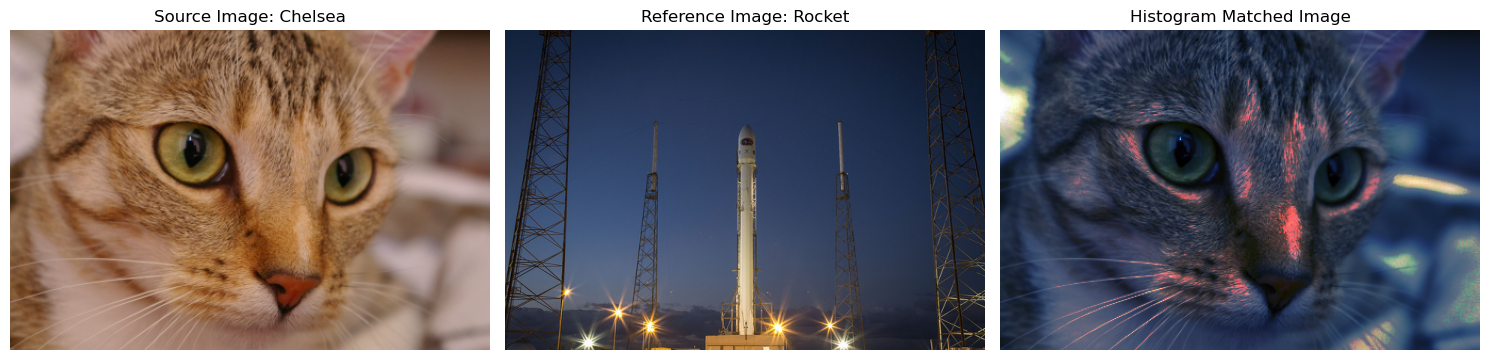

In [3]:
# Load the source and reference images
source_image = data.chelsea()
reference_image = data.rocket()

# Match the histogram of Chelsea image to the Rocket image
matched_image = exposure.match_histograms(
    source_image,
    reference_image,
    channel_axis=-1
)

# Display the images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(source_image)
plt.title('Source Image: Chelsea')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference_image)
plt.title('Reference Image: Rocket')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched_image)
plt.title('Histogram Matched Image')
plt.axis('off')

plt.tight_layout()
plt.show()